In [ ]:
from google.colab import files
files.upload()


Saving kaggle.json to kaggle (1).json


{'kaggle (1).json': b'{"username":"scarryy","key":"eae79e2cad5a5d2c65453a1263d245ca"}'}

In [ ]:
import os

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')

os.chmod('/root/.kaggle/kaggle.json', 600)

In [ ]:
!kaggle datasets download -d emmarex/plantdisease

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:17<00:00, 40.5MB/s]



In [ ]:
import zipfile

with zipfile.ZipFile('plantdisease.zip', 'r') as zip_ref:
    zip_ref.extractall()


In [ ]:
import os
import shutil
import random

os.makedirs("Dataset/Healthy", exist_ok=True)
os.makedirs("Dataset/Diseased", exist_ok=True)

In [ ]:
source_path = "PlantVillage"

healthy_images = []
diseased_images = []

for folder in os.listdir(source_path):
    folder_path = os.path.join(source_path, folder)

    if os.path.isdir(folder_path):
        for img in os.listdir(folder_path):
            img_path = os.path.join(folder_path, img)

            if "healthy" in folder.lower():
                healthy_images.append(img_path)
            else:
                diseased_images.append(img_path)

# Shuffle
random.shuffle(healthy_images)
random.shuffle(diseased_images)

# Limit
healthy_images = healthy_images[:3200]
diseased_images = diseased_images[:3200]

# Copy files
for img in healthy_images:
    shutil.copy(img, "Dataset/Healthy")

for img in diseased_images:
    shutil.copy(img, "Dataset/Diseased")

print("Dataset Created!")

Dataset Created!


In [ ]:
import os

print("Healthy:", len(os.listdir("Dataset/Healthy")))
print("Diseased:", len(os.listdir("Dataset/Diseased")))

Healthy: 3200
Diseased: 3200


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    'Dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

validation_generator = datagen.flow_from_directory(
    'Dataset',
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 5120 images belonging to 2 classes.
Found 1280 images belonging to 2 classes.


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Input(shape=(224,224,3)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 654s 4s/step - accuracy: 0.7146 - loss: 0.5520 - val_accuracy: 0.9094 - val_loss: 0.2470
Epoch 2/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.9143 - loss: 0.2316 - val_accuracy: 0.9289 - val_loss: 0.1719
Epoch 3/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 612s 4s/step - accuracy: 0.9443 - loss: 0.1527 - val_accuracy: 0.8930 - val_loss: 0.2616
Epoch 4/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 618s 4s/step - accuracy: 0.9588 - loss: 0.1217 - val_accuracy: 0.9539 - val_loss: 0.1214
Epoch 5/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - accuracy: 0.9453 - loss: 0.1475 - val_accuracy: 0.9352 - val_loss: 0.1802
Epoch 6/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 603s 4s/step - accuracy: 0.9805 - loss: 0.0562 - val_accuracy: 0.9656 - val_loss: 0.0976
Epoch 7/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 607s 4s/step - accuracy: 0.9770 - loss: 0.0615 - val_accuracy: 0.9398 - val_loss: 0.2166
Epoch 8/10
160/160 ━━━━━━━━━━━━━━━━━━━━ 605s 4s/step - accuracy: 0.9812 - loss: 0.0471 - val_accu

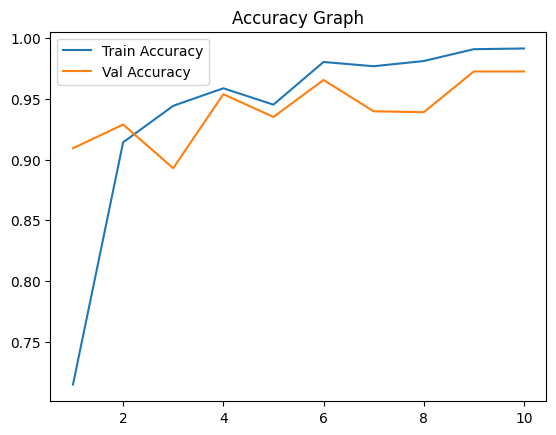

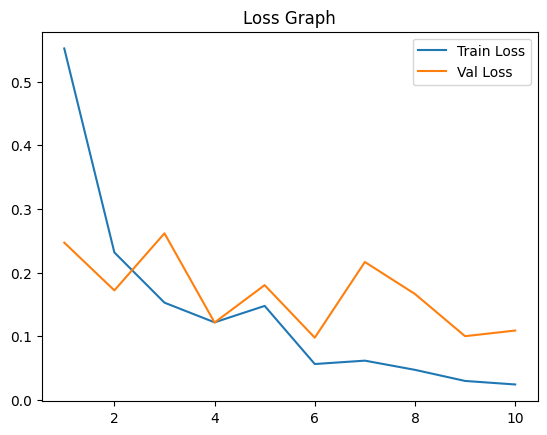

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history.history['accuracy']) + 1)

plt.plot(epochs, history.history['accuracy'], label='Train Accuracy')
plt.plot(epochs, history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy Graph")
plt.show()

plt.plot(epochs, history.history['loss'], label='Train Loss')
plt.plot(epochs, history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Graph")
plt.show()

In [ ]:
model.save("crop_model.h5")

In [ ]:
from google.colab import files
files.download("crop_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import files
uploaded = files.upload()

import numpy as np
from tensorflow.keras.preprocessing import image

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    print("Diseased Leaf ")
else:
    print("Healthy Leaf ")

Saving 000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.JPG to 000bf685-b305-408b-91f4-37030f8e62db___GH_HL Leaf 308.1.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
Diseased Leaf 
